<a href="https://colab.research.google.com/github/danangcorp/Analisis-Data-Pesanan-Restoran-Berdasarkan-Item-Waktu-dan-Pengeluaran-Konsumen/blob/main/Project_Akhir_DQLab_Danang_arya_saputra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Import Library

In [ ]:
import numpy as np # for numerical computing
import pandas as pd # for dataframe and manipulation
import seaborn as sns #for graphs and data visualization
from matplotlib import pyplot as plt
sns.set()
%matplotlib inline

#2. Data Collection and Processing

In [ ]:
df_menu = pd.read_csv('/content/menu_items.csv')

In [ ]:
df_menu.head()

,menu_item_id,item_name,category,price
0,101,Hamburger,American,12.95
1,102,Cheeseburger,American,13.95
2,103,Hot Dog,American,9.00
3,104,Veggie Burger,American,10.50
4,105,Mac & Cheese,American,7.00


In [ ]:
df_order = pd.read_csv('/content/order_details.csv')

In [ ]:
df_order.head()

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,1/1/23,11:38:36 AM,109.0
1,2,2,1/1/23,11:57:40 AM,108.0
2,3,2,1/1/23,11:57:40 AM,124.0
3,4,2,1/1/23,11:57:40 AM,117.0
4,5,2,1/1/23,11:57:40 AM,129.0


#3. Menggabungkan df_order dan df_menu berdasarkan item_id di df_order dan menu_item_id di df_menu.

In [ ]:
df_restorant = pd.merge(df_order, df_menu, left_on='item_id', right_on='menu_item_id', how='left')

print('DataFrame Hasil Penggabungan (df_resto) - 5 Baris Pertama:')
display(df_restorant.head())

DataFrame Hasil Penggabungan (df_resto) - 5 Baris Pertama:


,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,1,1,1/1/23,11:38:36 AM,109.0,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,1/1/23,11:57:40 AM,108.0,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,1/1/23,11:57:40 AM,124.0,124.0,Spaghetti,Italian,14.50
3,4,2,1/1/23,11:57:40 AM,117.0,117.0,Chicken Burrito,Mexican,12.95
4,5,2,1/1/23,11:57:40 AM,129.0,129.0,Mushroom Ravioli,Italian,15.50


Sekarang, df_restorant berisi semua kolom dari df_order dan df_menu, digabungkan berdasarkan ID item yang cocok. Kita dapat melihat item_name, category, dan price dari setiap item pesanan.

In [ ]:
df_restorant

,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,1,1,1/1/23,11:38:36 AM,109.0,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,1/1/23,11:57:40 AM,108.0,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,1/1/23,11:57:40 AM,124.0,124.0,Spaghetti,Italian,14.50
3,4,2,1/1/23,11:57:40 AM,117.0,117.0,Chicken Burrito,Mexican,12.95
4,5,2,1/1/23,11:57:40 AM,129.0,129.0,Mushroom Ravioli,Italian,15.50
...,...,...,...,...,...,...,...,...,...
12229,12230,5369,3/31/23,10:05:04 PM,109.0,109.0,Korean Beef Bowl,Asian,17.95
12230,12231,5369,3/31/23,10:05:04 PM,129.0,129.0,Mushroom Ravioli,Italian,15.50
12231,12232,5369,3/31/23,10:05:04 PM,120.0,120.0,Steak Torta,Mexican,13.95
12232,12233,5369,3/31/23,10:05:04 PM,122.0,122.0,Chips & Salsa,Mexican,7.00


In [ ]:
df_restorant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  12234 non-null  int64  
 1   order_id          12234 non-null  int64  
 2   order_date        12234 non-null  object 
 3   order_time        12234 non-null  object 
 4   item_id           12097 non-null  float64
 5   menu_item_id      12097 non-null  float64
 6   item_name         12097 non-null  object 
 7   category          12097 non-null  object 
 8   price             12097 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 860.3+ KB


#4. Memeriksa Dimensi Data (Shape dan Size)

In [ ]:
# Menampilkan jumlah baris dan kolom
print("\nDimensi data (baris, kolom):")
print(df_restorant.shape)


Dimensi data (baris, kolom):
(12234, 9)


In [ ]:
# Menampilkan jumlah total elemen dalam data
print("\nJumlah total elemen:")
print(df_restorant.size)


Jumlah total elemen:
110106


#5. Memeriksa Nama Kolom dan Tipe Data

In [ ]:
# Menampilkan nama-nama kolom
print("\nNama-nama kolom:")
print(df_restorant.columns)


Nama-nama kolom:
Index(['order_details_id', 'order_id', 'order_date', 'order_time', 'item_id',
       'menu_item_id', 'item_name', 'category', 'price'],
      dtype='object')


In [ ]:
# Menampilkan tipe data setiap kolom
print("\nTipe data setiap kolom:")
print(df_restorant.dtypes)


Tipe data setiap kolom:
order_details_id      int64
order_id              int64
order_date           object
order_time           object
item_id             float64
menu_item_id        float64
item_name            object
category             object
price               float64
dtype: object


#6. Membuat Copy Dataset

In [ ]:
df_restorant_copy = df_restorant.copy()
print('DataFrame df_resto_copy created:')
display(df_restorant_copy.head())

DataFrame df_resto_copy created:


,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,1,1,1/1/23,11:38:36 AM,109.0,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,1/1/23,11:57:40 AM,108.0,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,1/1/23,11:57:40 AM,124.0,124.0,Spaghetti,Italian,14.50
3,4,2,1/1/23,11:57:40 AM,117.0,117.0,Chicken Burrito,Mexican,12.95
4,5,2,1/1/23,11:57:40 AM,129.0,129.0,Mushroom Ravioli,Italian,15.50


#7. Mendapatkan Informasi Ringkas Data (Info dan Describe)

In [ ]:
# Menampilkan ringkasan statistik data numerik
print("\nRingkasan statistik data numerik:")
display(df_restorant_copy.describe())


Ringkasan statistik data numerik:


,order_details_id,order_id,item_id,menu_item_id,price
count,12234.000000,12234.000000,12097.000000,12097.000000,12097.000000
mean,6117.500000,2691.927415,115.202282,115.202282,13.161767
std,3531.795931,1546.026261,9.387580,9.387580,3.986392
min,1.000000,1.000000,101.000000,101.000000,5.000000
25%,3059.250000,1351.250000,107.000000,107.000000,10.500000
50%,6117.500000,2710.000000,114.000000,114.000000,13.950000
75%,9175.750000,4020.000000,123.000000,123.000000,16.500000
max,12234.000000,5370.000000,132.000000,132.000000,19.950000


In [ ]:
# Menampilkan ringkasan statistik semua kolom (termasuk non-numerik)
print("\nRingkasan statistik semua kolom:")
display(df_restorant_copy.describe(include='all'))


Ringkasan statistik semua kolom:


,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
count,12234.000000,12234.000000,12234,12234,12097.000000,12097.000000,12097,12097,12097.000000
unique,NaN,NaN,90,5010,NaN,NaN,32,4,NaN
top,NaN,NaN,2/1/23,12:24:36 PM,NaN,NaN,Hamburger,Asian,NaN
freq,NaN,NaN,188,16,NaN,NaN,622,3470,NaN
mean,6117.500000,2691.927415,NaN,NaN,115.202282,115.202282,NaN,NaN,13.161767
std,3531.795931,1546.026261,NaN,NaN,9.387580,9.387580,NaN,NaN,3.986392
min,1.000000,1.000000,NaN,NaN,101.000000,101.000000,NaN,NaN,5.000000
25%,3059.250000,1351.250000,NaN,NaN,107.000000,107.000000,NaN,NaN,10.500000
50%,6117.500000,2710.000000,NaN,NaN,114.000000,114.000000,NaN,NaN,13.950000
75%,9175.750000,4020.000000,NaN,NaN,123.000000,123.000000,NaN,NaN,16.500000


#8. Menghitung Jumlah Nilai Unik

In [ ]:
# Menampilkan jumlah nilai unik di setiap kolom
print("\nJumlah nilai unik per kolom:")
display(df_restorant_copy.nunique())


Jumlah nilai unik per kolom:


,0
order_details_id,12234
order_id,5370
order_date,90
order_time,5010
item_id,32
menu_item_id,32
item_name,32
category,4
price,14


#9. Memeriksa Data yang Hilang (Missing Values)

In [ ]:
# Memeriksa apakah ada nilai null di setiap sel
print("Status nilai null di setiap sel:")
display(df_restorant_copy.isnull())

Status nilai null di setiap sel:


,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
12229,False,False,False,False,False,False,False,False,False
12230,False,False,False,False,False,False,False,False,False
12231,False,False,False,False,False,False,False,False,False
12232,False,False,False,False,False,False,False,False,False


In [ ]:
# Menghitung jumlah nilai null di setiap kolom
miss = df_restorant_copy.isnull().sum()
print("\nJumlah nilai null per kolom:")
print(miss)


Jumlah nilai null per kolom:
order_details_id      0
order_id              0
order_date            0
order_time            0
item_id             137
menu_item_id        137
item_name           137
category            137
price               137
dtype: int64


In [ ]:
# Menghitung persentase nilai null di setiap kolom
misspercent = (df_restorant_copy.isnull().sum()/len(df_restorant_copy))* 100
print("\nPersentase nilai null per kolom:")
print(misspercent)


Persentase nilai null per kolom:
order_details_id    0.00000
order_id            0.00000
order_date          0.00000
order_time          0.00000
item_id             1.11983
menu_item_id        1.11983
item_name           1.11983
category            1.11983
price               1.11983
dtype: float64


In [ ]:
# Menggabungkan jumlah dan persentase nilai null dalam satu tabel
m = pd.concat([miss,misspercent],axis=1,keys=['Total','Missing%'])
print("\nTabel jumlah dan persentase nilai null:")
print(m)


Tabel jumlah dan persentase nilai null:
                  Total  Missing%
order_details_id      0   0.00000
order_id              0   0.00000
order_date            0   0.00000
order_time            0   0.00000
item_id             137   1.11983
menu_item_id        137   1.11983
item_name           137   1.11983
category            137   1.11983
price               137   1.11983


#10. Visualisasi Data yang Hilang

<Axes: >

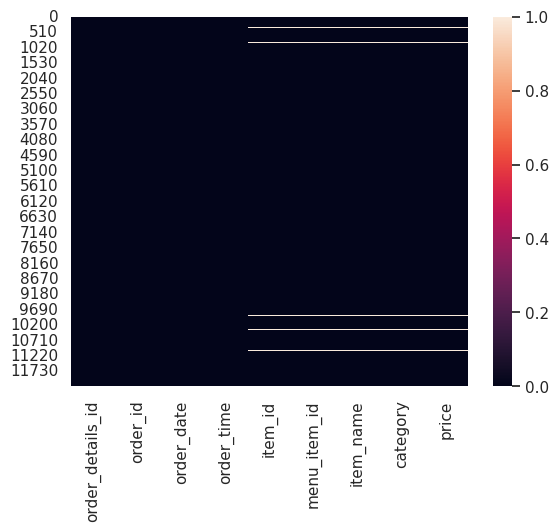

In [ ]:
sns.heatmap(df_restorant_copy.isnull())

#11. Menangani Nilai yang Hilang (Menghapus Baris)

In [ ]:
df_restorant_copy.dropna(inplace=True)
print("DataFrame after dropping rows with missing values - 5 Baris Pertama:")
display(df_restorant_copy.head())
print("\nNew shape of the DataFrame after dropping rows with missing values:")
print(df_restorant_copy.shape)

DataFrame after dropping rows with missing values - 5 Baris Pertama:


,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,1,1,1/1/23,11:38:36 AM,109.0,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,1/1/23,11:57:40 AM,108.0,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,1/1/23,11:57:40 AM,124.0,124.0,Spaghetti,Italian,14.50
3,4,2,1/1/23,11:57:40 AM,117.0,117.0,Chicken Burrito,Mexican,12.95
4,5,2,1/1/23,11:57:40 AM,129.0,129.0,Mushroom Ravioli,Italian,15.50



New shape of the DataFrame after dropping rows with missing values:
(12097, 9)


**Reasoning**:
I need to verify that all missing values have been successfully removed from `df_restorant_copy` by checking the count of null values in each column. This confirms the successful completion of the data cleaning step.



#12. Memeriksa Kembali Data yang Hilang Setelah Penanganan

In [ ]:
print("Missing values after dropping rows:")
display(df_restorant_copy.isnull().sum())


Missing values after dropping rows:


,0
order_details_id,0
order_id,0
order_date,0
order_time,0
item_id,0
menu_item_id,0
item_name,0
category,0
price,0


#13. Visualisasi Data yang Hilang Setelah Penanganan

<Axes: >

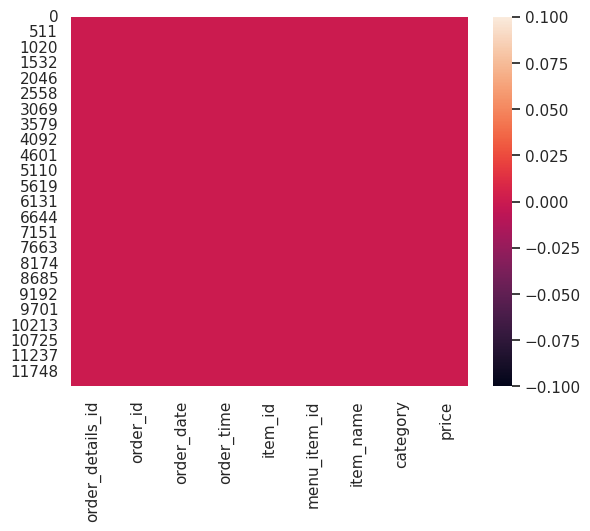

In [ ]:
sns.heatmap(df_restorant_copy.isnull())

#14. Memeriksa Dimensi Data Setelah Penanganan Nilai Hilang

In [ ]:
df_restorant_copy.shape

(12097, 9)

#15. Mendapatkan Ringkasan Statistik Setelah Penanganan Nilai Hilang

In [ ]:
df_restorant_copy.describe(include="all")

,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
count,12097.000000,12097.000000,12097,12097,12097.000000,12097.000000,12097,12097,12097.000000
unique,NaN,NaN,90,4985,NaN,NaN,32,4,NaN
top,NaN,NaN,2/1/23,12:24:36 PM,NaN,NaN,Hamburger,Asian,NaN
freq,NaN,NaN,186,16,NaN,NaN,622,3470,NaN
mean,6118.950897,2692.569149,NaN,NaN,115.202282,115.202282,NaN,NaN,13.161767
std,3531.337208,1545.826452,NaN,NaN,9.387580,9.387580,NaN,NaN,3.986392
min,1.000000,1.000000,NaN,NaN,101.000000,101.000000,NaN,NaN,5.000000
25%,3064.000000,1353.000000,NaN,NaN,107.000000,107.000000,NaN,NaN,10.500000
50%,6119.000000,2711.000000,NaN,NaN,114.000000,114.000000,NaN,NaN,13.950000
75%,9175.000000,4020.000000,NaN,NaN,123.000000,123.000000,NaN,NaN,16.500000


#16. Pengecekan Outlier pada Kolom Price

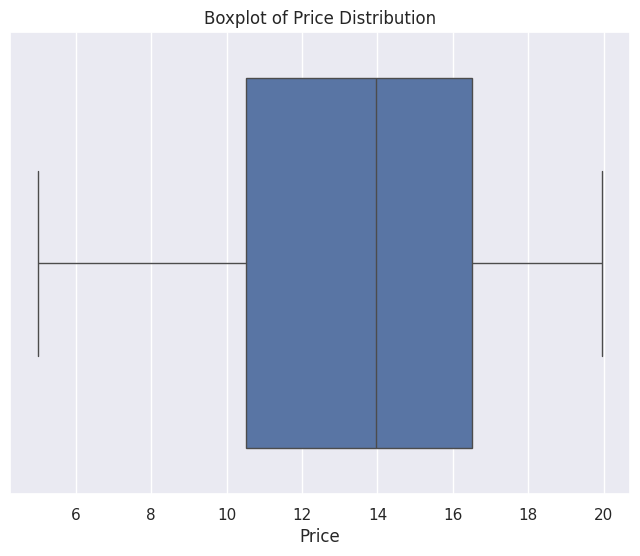

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_restorant_copy['price'])
plt.xlabel('Price')
plt.title('Boxplot of Price Distribution')
plt.show()


#17. Menangani Duplikasi Data

In [ ]:
# Memeriksa baris yang terduplikasi
print("Status duplikasi baris:")
display(df_restorant_copy.duplicated())

Status duplikasi baris:


,0
0,False
1,False
2,False
3,False
4,False
...,...
12229,False
12230,False
12231,False
12232,False


In [ ]:
df_restorant_copy.duplicated().sum()

np.int64(0)

In [ ]:
print('Tipe data kolom order_date di df_restorant_copy:')
df_restorant_copy.info()

Tipe data kolom order_date di df_restorant_copy:
<class 'pandas.core.frame.DataFrame'>
Index: 12097 entries, 0 to 12233
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  12097 non-null  int64  
 1   order_id          12097 non-null  int64  
 2   order_date        12097 non-null  object 
 3   order_time        12097 non-null  object 
 4   item_id           12097 non-null  float64
 5   menu_item_id      12097 non-null  float64
 6   item_name         12097 non-null  object 
 7   category          12097 non-null  object 
 8   price             12097 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 945.1+ KB


In [ ]:
df_restorant_copy['order_date'] = pd.to_datetime(df_restorant_copy['order_date'], format='%m/%d/%y', errors='coerce')
df_restorant_copy['order_time'] = pd.to_datetime(df_restorant_copy['order_time'], format='%I:%M:%S %p', errors='coerce')

print('\nUpdated DataFrame Info for df_restorant_copy:')
df_restorant_copy.info()


Updated DataFrame Info for df_restorant_copy:
<class 'pandas.core.frame.DataFrame'>
Index: 12097 entries, 0 to 12233
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12097 non-null  int64         
 1   order_id          12097 non-null  int64         
 2   order_date        12097 non-null  datetime64[ns]
 3   order_time        12097 non-null  datetime64[ns]
 4   item_id           12097 non-null  float64       
 5   menu_item_id      12097 non-null  float64       
 6   item_name         12097 non-null  object        
 7   category          12097 non-null  object        
 8   price             12097 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(2)
memory usage: 945.1+ KB


In [ ]:
df_restorant_copy

,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,1,1,2023-01-01,1900-01-01 11:38:36,109.0,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,2023-01-01,1900-01-01 11:57:40,108.0,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,2023-01-01,1900-01-01 11:57:40,124.0,124.0,Spaghetti,Italian,14.50
3,4,2,2023-01-01,1900-01-01 11:57:40,117.0,117.0,Chicken Burrito,Mexican,12.95
4,5,2,2023-01-01,1900-01-01 11:57:40,129.0,129.0,Mushroom Ravioli,Italian,15.50
...,...,...,...,...,...,...,...,...,...
12229,12230,5369,2023-03-31,1900-01-01 22:05:04,109.0,109.0,Korean Beef Bowl,Asian,17.95
12230,12231,5369,2023-03-31,1900-01-01 22:05:04,129.0,129.0,Mushroom Ravioli,Italian,15.50
12231,12232,5369,2023-03-31,1900-01-01 22:05:04,120.0,120.0,Steak Torta,Mexican,13.95
12232,12233,5369,2023-03-31,1900-01-01 22:05:04,122.0,122.0,Chips & Salsa,Mexican,7.00


### Menggabungkan `order_date` ke `order_time` dan Memformat Ulang `order_date`

Untuk memenuhi permintaan Anda, kita akan melakukan langkah-langkah berikut:
1.  **Menggabungkan Tanggal dan Waktu**: Kolom `order_time` saat ini memiliki tanggal `1900-01-01`. Kita akan mengambil tanggal sebenarnya dari kolom `order_date` dan menggabungkannya dengan waktu dari kolom `order_time` untuk membuat *timestamp* lengkap di kolom `order_time`.
2.  **Memformat Ulang `order_date`**: Setelah tanggalnya dipindahkan, kita akan mengubah kolom `order_date` menjadi format string yang hanya menampilkan tahun dan bulan (YYYY-MM).

In [ ]:
import datetime as dt
import pandas as pd

# Memastikan kolom 'order_date' dan 'order_time' bertipe datetime sebelum digunakan
df_restorant_copy['order_date'] = pd.to_datetime(df_restorant_copy['order_date'], errors='coerce')
df_restorant_copy['order_time'] = pd.to_datetime(df_restorant_copy['order_time'], errors='coerce')

# Menggabungkan tanggal dari 'order_date' ke 'order_time'
df_restorant_copy['order_time'] = df_restorant_copy.apply(
    lambda row: dt.datetime.combine(row['order_date'].date(), row['order_time'].time()),
    axis=1
)

# Kolom 'order_date' tetap datetime, sesuai permintaan Anda.

print('DataFrame setelah perubahan (order_time diperbarui) - 5 Baris Pertama:')
display(df_restorant_copy.head())

print('\nInformasi DataFrame setelah perubahan tipe data:')
df_restorant_copy.info()

DataFrame setelah perubahan (order_time diperbarui) - 5 Baris Pertama:


,order_details_id,order_id,order_date,order_time,item_id,menu_item_id,item_name,category,price
0,1,1,2023-01-01,2023-01-01 11:38:36,109.0,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,2023-01-01,2023-01-01 11:57:40,108.0,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,2023-01-01,2023-01-01 11:57:40,124.0,124.0,Spaghetti,Italian,14.50
3,4,2,2023-01-01,2023-01-01 11:57:40,117.0,117.0,Chicken Burrito,Mexican,12.95
4,5,2,2023-01-01,2023-01-01 11:57:40,129.0,129.0,Mushroom Ravioli,Italian,15.50



Informasi DataFrame setelah perubahan tipe data:
<class 'pandas.core.frame.DataFrame'>
Index: 12097 entries, 0 to 12233
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  12097 non-null  int64         
 1   order_id          12097 non-null  int64         
 2   order_date        12097 non-null  datetime64[ns]
 3   order_time        12097 non-null  datetime64[ns]
 4   item_id           12097 non-null  float64       
 5   menu_item_id      12097 non-null  float64       
 6   item_name         12097 non-null  object        
 7   category          12097 non-null  object        
 8   price             12097 non-null  float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(2)
memory usage: 945.1+ KB


In [ ]:
from google.colab import files

df_restorant_copy.to_csv("/content/df_resto_copy.csv", index=False)
files.download("/content/df_resto_copy.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>